# Insula–DMN Pilot Analysis (Improved)

This notebook turns the earlier exploratory workflow into a more **scientific mini-report**.  
It is designed to help you produce a cleaner pilot analysis that could be shown to a potential supervisor.

## Research Question
Do functional connectivity patterns in an open fMRI dataset provide a useful proof-of-concept for studying interactions between the **insula** and **default mode network (DMN)**?

## Why this notebook is stronger
This version adds:

- a short scientific framing
- reproducible path checking
- extraction of atlas labels
- targeted identification of **insula** and candidate **DMN** nodes
- a connectivity summary table
- an optional simple graph-theory style analysis

## Notes
- This dataset is useful as a **proof of concept**, even if it is not the final resting-state dataset for your thesis work.
- The strongest thesis-facing version would later use a true resting-state dataset plus trait-anxiety measures.

## Methods

**Dataset.** An openly available preprocessed fMRI image is used as a demonstration dataset.

**Atlas.** Brain regions are defined using the Harvard-Oxford cortical atlas.

**Signal extraction.** Regional time series are extracted using `NiftiLabelsMasker`.

**Connectivity.** Pairwise Pearson correlations are computed across atlas regions to generate a functional connectivity matrix.

**Target regions.** Special attention is given to the **insula** and likely **DMN-related regions**, especially:
- medial prefrontal cortex
- posterior cingulate / precuneus-related regions
- angular gyrus / inferior parietal regions

Because atlas naming conventions vary, this notebook first lists labels so you can verify the final region choices explicitly.

In [1]:
# Imports
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

In [2]:
# Fetch the Harvard-Oxford cortical atlas
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
print("Atlas maps:", atlas.maps)
print("Number of labels:", len(atlas.labels))

[fetch_atlas_harvard_oxford] Dataset found in /home/john-walkey/nilearn_data/fsl
Atlas maps: 
<class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91)
affine:
[[   2.    0.    0.  -90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 48.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0


## Resolve the fMRI file path automatically

In [3]:
# Candidate locations based on your earlier troubleshooting
candidate_paths = [
    "/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz",
    "/home/john-walkey/.nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz",
]

existing = [p for p in candidate_paths if os.path.exists(p)]
print("Existing candidate paths:")
for p in existing:
    print("  ", p)

if not existing:
    # Fallback search
    matches = list(Path("/home/john-walkey").rglob("*sub-pixar123*bold.nii.gz"))
    print("\nFallback search results:")
    for m in matches:
        print("  ", m)
    if matches:
        bold_file = str(matches[0])
    else:
        raise FileNotFoundError("Could not find the BOLD file. Check the path or rerun the search.")
else:
    bold_file = existing[0]

print("\nSelected bold_file:")
print(bold_file)

Existing candidate paths:
   /home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

Selected bold_file:
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


## Extract regional time series

In [4]:
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize=True)
time_series = masker.fit_transform(bold_file)
print("time_series shape:", time_series.shape)

/tmp/ipykernel_13333/2245145790.py:2: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(bold_file)


time_series shape: (168, 48)


## Inspect atlas labels

This is important because different atlases use slightly different region names.
You should confirm the exact labels corresponding to:

- left insula
- right insula
- medial prefrontal cortex candidates
- posterior cingulate / precuneus candidates
- angular gyrus / inferior parietal candidates

In [5]:
labels_df = pd.DataFrame({
    "index": list(range(len(atlas.labels))),
    "label": atlas.labels
})
labels_df.head(20)

,index,label
0,0,Background
1,1,Frontal Pole
2,2,Insular Cortex
3,3,Superior Frontal Gyrus
4,4,Middle Frontal Gyrus
5,5,"Inferior Frontal Gyrus, pars triangularis"
6,6,"Inferior Frontal Gyrus, pars opercularis"
7,7,Precentral Gyrus
8,8,Temporal Pole
9,9,"Superior Temporal Gyrus, anterior division"


In [6]:
# Show all labels containing terms relevant to your hypothesis
keywords = ["insula", "cing", "precune", "frontal medial", "frontal pole", "angular", "parietal", "default"]
mask = labels_df["label"].str.lower().apply(lambda s: any(k in s for k in keywords))
labels_df[mask].reset_index(drop=True)

,index,label
0,1,Frontal Pole
1,2,Insular Cortex
2,5,"Inferior Frontal Gyrus, pars triangularis"
3,18,Superior Parietal Lobule
4,21,Angular Gyrus
5,25,Frontal Medial Cortex
6,28,Paracingulate Gyrus
7,29,"Cingulate Gyrus, anterior division"
8,30,"Cingulate Gyrus, posterior division"
9,31,Precuneous Cortex


## Compute the full functional connectivity matrix

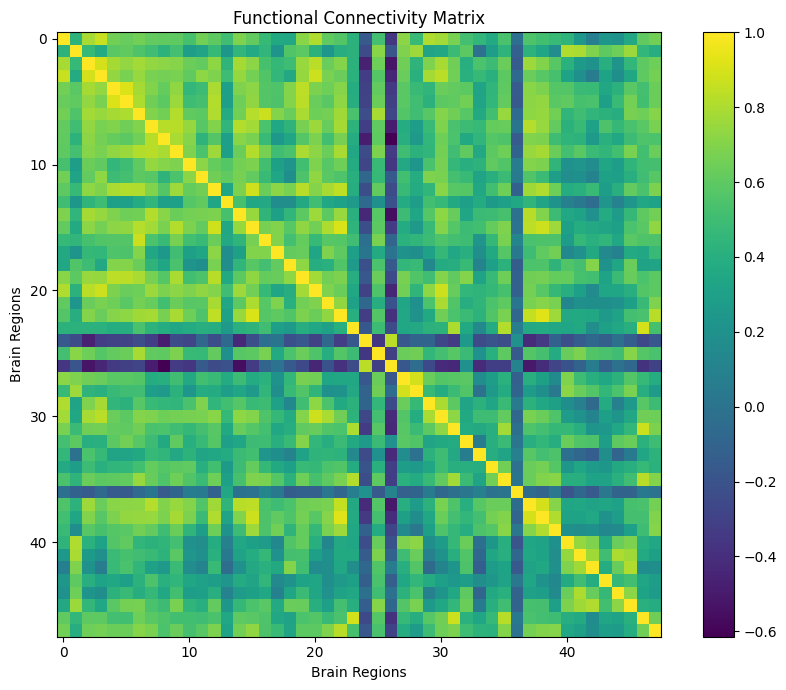

In [7]:
correlation_matrix = np.corrcoef(time_series.T)

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.title("Functional Connectivity Matrix")
plt.xlabel("Brain Regions")
plt.ylabel("Brain Regions")
plt.tight_layout()
plt.show()

### Preliminary interpretation

- Warm colors indicate stronger positive correlations.
- Cooler colors indicate weaker or negative correlations.
- Block-like patterns near the diagonal often suggest network structure or regional clustering.

This figure is useful as an initial demonstration that the analysis pipeline is working.

## Define target regions

In [8]:
# Inspect labels manually and then edit these lists if needed.
# The defaults below use keyword matching so the notebook can run with minimal editing.

label_lookup = {i: str(lbl) for i, lbl in enumerate(atlas.labels)}
lower_lookup = {i: str(lbl).lower() for i, lbl in enumerate(atlas.labels)}

insula_idx = [i for i, lbl in lower_lookup.items() if "insula" in lbl]

# Candidate DMN-related regions in this atlas:
# - medial frontal / frontal medial cortex as rough mPFC candidates
# - posterior cingulate or precuneus if present
# - angular gyrus or inferior parietal as angular/IPL candidates
dmn_idx = [
    i for i, lbl in lower_lookup.items()
    if ("frontal medial" in lbl)
    or ("frontal pole" in lbl)
    or ("cing" in lbl)
    or ("precune" in lbl)
    or ("angular" in lbl)
    or ("supramarginal" in lbl)
    or ("parietal" in lbl and "opercular" not in lbl)
]

print("Insula indices:")
for i in insula_idx:
    print(i, "-", label_lookup[i])

print("\nCandidate DMN-related indices:")
for i in dmn_idx:
    print(i, "-", label_lookup[i])

Insula indices:
2 - Insular Cortex

Candidate DMN-related indices:
1 - Frontal Pole
5 - Inferior Frontal Gyrus, pars triangularis
18 - Superior Parietal Lobule
19 - Supramarginal Gyrus, anterior division
20 - Supramarginal Gyrus, posterior division
21 - Angular Gyrus
25 - Frontal Medial Cortex
28 - Paracingulate Gyrus
29 - Cingulate Gyrus, anterior division
30 - Cingulate Gyrus, posterior division
31 - Precuneous Cortex


## Summarize insula-to-DMN connectivity

This table is one of the most useful additions for showing a supervisor that you are moving beyond a generic heat map toward a **testable network hypothesis**.

In [9]:
rows = []
for i in insula_idx:
    for j in dmn_idx:
        if i == j:
            continue
        rows.append({
            "insula_index": i,
            "insula_label": label_lookup[i],
            "target_index": j,
            "target_label": label_lookup[j],
            "correlation": correlation_matrix[i, j]
        })

insula_dmn_df = pd.DataFrame(rows).sort_values("correlation", ascending=False).reset_index(drop=True)
insula_dmn_df.head(20)

,insula_index,insula_label,target_index,target_label,correlation
0,2,Insular Cortex,20,"Supramarginal Gyrus, posterior division",0.831568
1,2,Insular Cortex,30,"Cingulate Gyrus, posterior division",0.789673
2,2,Insular Cortex,19,"Supramarginal Gyrus, anterior division",0.753522
3,2,Insular Cortex,5,"Inferior Frontal Gyrus, pars triangularis",0.741003
4,2,Insular Cortex,29,"Cingulate Gyrus, anterior division",0.690324
5,2,Insular Cortex,31,Precuneous Cortex,0.646889
6,2,Insular Cortex,25,Frontal Medial Cortex,0.645528
7,2,Insular Cortex,21,Angular Gyrus,0.630801
8,2,Insular Cortex,18,Superior Parietal Lobule,0.497120
9,2,Insular Cortex,1,Frontal Pole,0.470276


In [10]:
# Save the summary table if you want to use it in Word/Excel later
out_csv = "insula_dmn_connectivity_summary.csv"
insula_dmn_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

Saved: insula_dmn_connectivity_summary.csv


## Plot the strongest insula connections

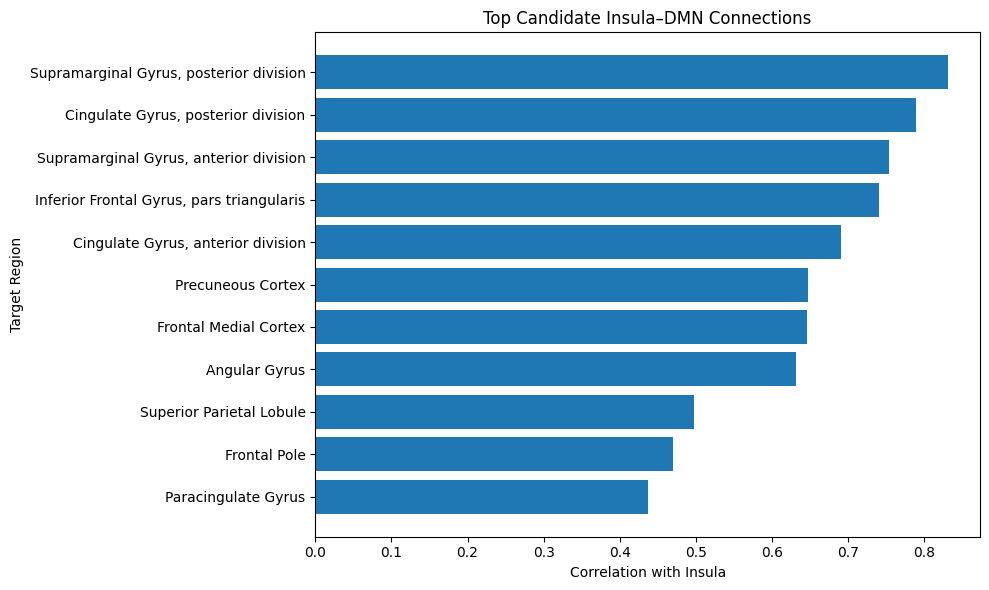

In [11]:
top_n = 12
top_df = insula_dmn_df.head(top_n).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_df["target_label"], top_df["correlation"])
plt.gca().invert_yaxis()
plt.xlabel("Correlation with Insula")
plt.ylabel("Target Region")
plt.title("Top Candidate Insula–DMN Connections")
plt.tight_layout()
plt.show()

## Simple graph-style metrics (introductory)

This is not a full graph-theory analysis, but it introduces the logic.

Here we create a thresholded connectivity matrix and compute a simple **degree** measure:
how many above-threshold connections each node has.

In [12]:
threshold = 0.30  # You can adjust this
adjacency = (correlation_matrix > threshold).astype(int)
np.fill_diagonal(adjacency, 0)

degree = adjacency.sum(axis=1)

degree_df = pd.DataFrame({
    "index": list(range(len(degree))),
    "label": [label_lookup[i] for i in range(len(degree))],
    "degree": degree
}).sort_values("degree", ascending=False).reset_index(drop=True)

degree_df.head(15)

,index,label,degree
0,6,"Inferior Frontal Gyrus, pars opercularis",44
1,19,"Supramarginal Gyrus, anterior division",44
2,7,Precentral Gyrus,43
3,4,Middle Frontal Gyrus,43
4,12,"Middle Temporal Gyrus, posterior division",43
5,15,"Inferior Temporal Gyrus, posterior division",43
6,46,Planum Temporale,43
7,9,"Superior Temporal Gyrus, anterior division",43
8,35,"Parahippocampal Gyrus, posterior division",43
9,37,"Temporal Fusiform Cortex, anterior division",43


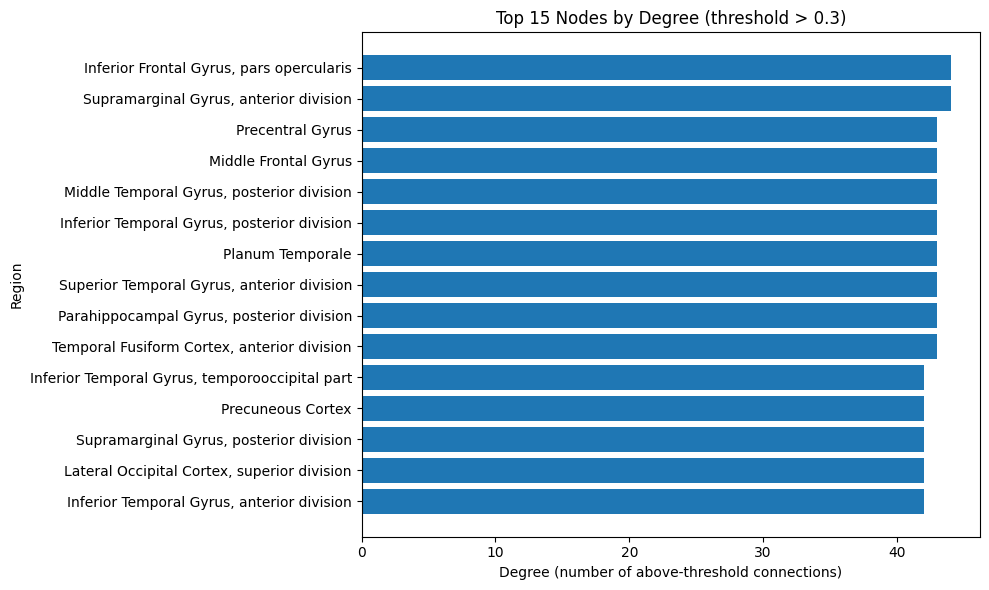

In [13]:
plt.figure(figsize=(10, 6))
top_degree = degree_df.head(15)
plt.barh(top_degree["label"], top_degree["degree"])
plt.gca().invert_yaxis()
plt.xlabel("Degree (number of above-threshold connections)")
plt.ylabel("Region")
plt.title(f"Top 15 Nodes by Degree (threshold > {threshold})")
plt.tight_layout()
plt.show()

## Discussion

This pilot analysis demonstrates a workable Python-based workflow for region-wise functional connectivity analysis using an open fMRI dataset.

### What this notebook now demonstrates better than the original version
- reproducible data loading
- explicit atlas inspection
- targeted extraction of **insula–DMN candidate connections**
- a summary table suitable for export
- a first step toward graph-theory style analysis

### Important limitations
- The current example dataset is mainly a **proof of concept**
- It is not yet tied to **trait anxiety scores**
- Final thesis-facing work should use:
  - a true resting-state dataset
  - clearly defined behavioral or clinical measures
  - more careful preprocessing and region definition
  - group-level statistics

### A good sentence for a supervisor meeting
"I built a preliminary Python workflow that extracts atlas-based regional signals, computes a functional connectivity matrix, and summarizes candidate insula–DMN connections from an open fMRI dataset."

That is a much stronger statement than simply saying you made a heat map.

## Next steps

1. Verify the exact atlas labels you want to treat as:
   - left insula
   - right insula
   - medial prefrontal cortex
   - posterior cingulate / precuneus
   - angular gyrus

2. Replace the proof-of-concept dataset with a true **resting-state dataset**

3. Add subject-level variables such as:
   - trait anxiety
   - age
   - sex
   - clinical status

4. Move from exploratory plots to:
   - group comparisons
   - regression models
   - graph metrics such as clustering, modularity, and efficiency